ĐỀ TÀI: PHÂN TÍCH BIẾN ĐỘNG GIÁ XĂNG DẦU TẠI VIỆT NAM GIAI ĐOẠN 2020-2025

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pyspark.sql import SparkSession
from pyspark.sql.functions import col, year

In [2]:
# Tạo Spark Session
spark = SparkSession.builder \
    .appName("PhanTichXangDau") \
    .getOrCreate()

# Đọc file CSV
df = spark.read.csv(
    "data/Petrolimex_oilprice.csv",
    header=True,
    inferSchema=True
)

# Hiển thị dữ liệu
df.show(5)

+----------+-------------------------+-------------------------+---------------------------+---------------------------+-----------------------------+-----------------------------+-------------------------------+-------------------------------+-----------------------+-----------------------+-----------------------+-----------------------+-----------------------+-----------------------+
|      Date|Xăng RON 95-V zone1_price|Xăng RON 95-V zone2_price|Xăng RON 95-III zone1_price|Xăng RON 95-III zone2_price|Xăng E5 RON 92-II zone1_price|Xăng E5 RON 92-II zone2_price|Xăng E10 RON 95-III zone1_price|Xăng E10 RON 95-III zone2_price|DO 0,05S-II zone1_price|DO 0,05S-II zone2_price|DO 0,001S-V zone1_price|DO 0,001S-V zone2_price|Dầu hỏa 2-K zone1_price|Dầu hỏa 2-K zone2_price|
+----------+-------------------------+-------------------------+---------------------------+---------------------------+-----------------------------+-----------------------------+-------------------------------+----------

In [3]:
# Chuyển cột Date sang kiểu ngày
df = df.withColumn(
    "Date",
    col("Date").cast("date")
)

# Tạo cột Year
df = df.withColumn(
    "Year",
    year(col("Date"))
)

# Lọc dữ liệu từ 2020–2025
df_filtered = df.filter(
    (col("Year") >= 2020) &
    (col("Year") <= 2025)
)

# Hiển thị dữ liệu sau lọc
df_filtered.select(
    "Date",
    "Year"
).show(5)

print("Số dòng dữ liệu:")
print(df_filtered.count())

+----------+----+
|      Date|Year|
+----------+----+
|2020-01-15|2020|
|2020-01-30|2020|
|2020-02-14|2020|
|2020-02-29|2020|
|2020-03-15|2020|
+----------+----+
only showing top 5 rows

Số dòng dữ liệu:
225


In [4]:
# Chuyển sang Pandas
pandas_df = df_filtered.toPandas()

# Chọn cột RON95
xang = pandas_df[
    ['Date', 'Xăng RON 95-V zone1_price']
]

# Xóa giá trị thiếu
xang = xang.dropna()

# Đổi tên cột
xang.columns = ['Date', 'Gia_xang']

xang.head()

,Date,Gia_xang
79,2022-12-01,23830.0
80,2022-12-12,22330.0
81,2022-12-21,21830.0
82,2023-01-01,22930.0
83,2023-01-03,23280.0


In [5]:
gia_max = np.max(xang['Gia_xang'])
gia_min = np.min(xang['Gia_xang'])
gia_tb = np.mean(xang['Gia_xang'])

print("Giá cao nhất:", gia_max)
print("Giá thấp nhất:", gia_min)
print("Giá trung bình:", round(gia_tb, 2))

Giá cao nhất: 26270.0
Giá thấp nhất: 19410.0
Giá trung bình: 22297.19


In [7]:
# TOP 3 cao nhất
top3_cao = xang.sort_values(
    by='Gia_xang',
    ascending=False
).head(3)

print("TOP 3 giá cao nhất:")
display(top3_cao)

# TOP 3 thấp nhất
top3_thap = xang.sort_values(
    by='Gia_xang',
    ascending=True
).head(3)

print("TOP 3 giá thấp nhất:")
display(top3_thap)

TOP 3 giá cao nhất:


,Date,Gia_xang
108,2023-09-21,26270.0
134,2024-04-17,25760.0
136,2024-05-02,25480.0


TOP 3 giá thấp nhất:


,Date,Gia_xang
186,2025-04-17,19410.0
223,2025-12-25,19540.0
185,2025-04-10,19580.0


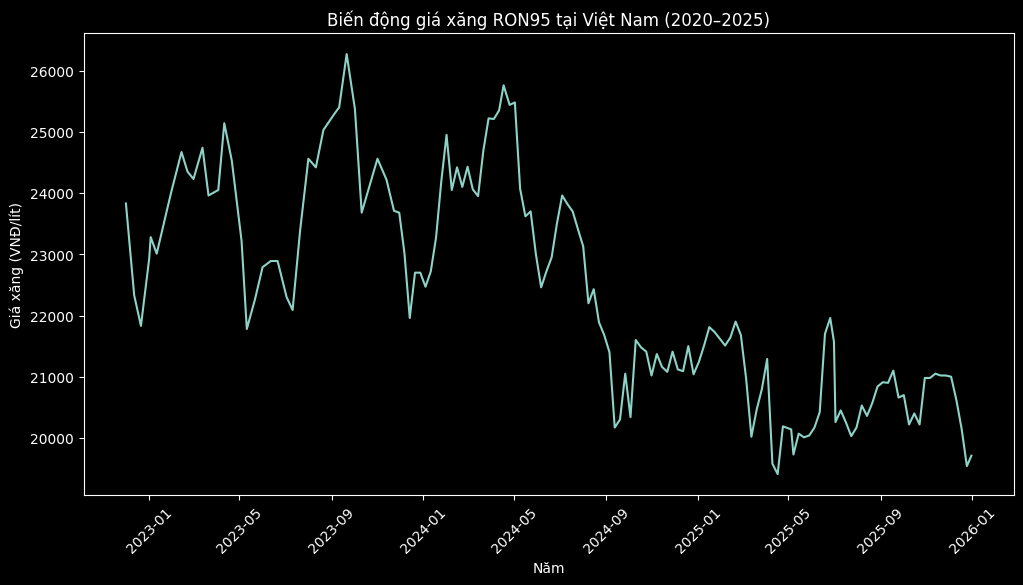

In [8]:
plt.figure(figsize=(12,6))

plt.plot(
    xang['Date'],
    xang['Gia_xang']
)

plt.title(
    'Biến động giá xăng RON95 tại Việt Nam (2020–2025)'
)

plt.xlabel('Năm')
plt.ylabel('Giá xăng (VNĐ/lít)')

plt.xticks(rotation=45)

plt.show()

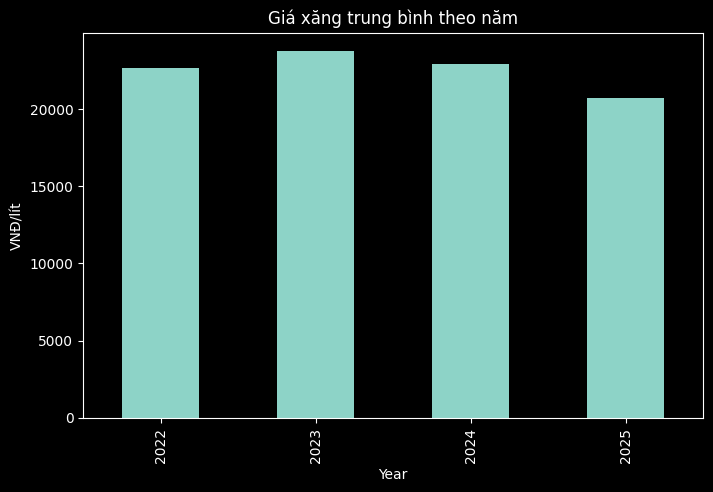

In [9]:
xang['Year'] = pd.to_datetime(
    xang['Date']
).dt.year

gia_tb_nam = xang.groupby(
    'Year'
)['Gia_xang'].mean()

plt.figure(figsize=(8,5))

gia_tb_nam.plot(kind='bar')

plt.title(
    'Giá xăng trung bình theo năm'
)

plt.ylabel('VNĐ/lít')

plt.show()

1. Giá xăng RON95 tại Việt Nam biến động như thế nào trong giai đoạn 2020–2025?
2. Tại sao giá xăng RON95 lại có biến động mạnh trong giai đoạn 2020–2025?
3. Thời điểm nào giá xăng RON95 đạt mức cao nhất?
4. Thời điểm nào giá xăng RON95 đạt mức thấp nhất?
5. Năm nào có giá xăng trung bình cao nhất?
6. Mức chênh lệch giữa giá cao nhất và thấp nhất là bao nhiêu?
7. Sau giai đoạn tăng mạnh, giá xăng có xu hướng giảm hay tiếp tục tăng?
